# Yhdistäminen

In [2]:
from pymongo import MongoClient
import pandas as pd
import time

client = MongoClient("mongodb://localhost:27017/")
db = client['US-Accidents']
collection = db['accidents']

# Chunkitetaan data ja ladataan sisääm

In [5]:
count = collection.count_documents({})
print(f"Dokumentteja MongoDB:ssä: {count}")

if count == 0:
    chunk_size = 10000
    total = 0
    for chunk in pd.read_csv("US_Accidents_March23.csv", chunksize=chunk_size):
        records = chunk.to_dict("records")
        collection.insert_many(records)
        total += len(records)
        print(f"Ladattu: {total} riviä...")
    print(f"Valmis! Yhteensä {total} dokumenttia.")
else:
    print("Data on jo olemassa, ohitetaan lataus!")

Dokumentteja MongoDB:ssä: 0
Ladattu: 10000 riviä...
Ladattu: 20000 riviä...
Ladattu: 30000 riviä...
Ladattu: 40000 riviä...
Ladattu: 50000 riviä...
Ladattu: 60000 riviä...
Ladattu: 70000 riviä...
Ladattu: 80000 riviä...
Ladattu: 90000 riviä...
Ladattu: 100000 riviä...
Ladattu: 110000 riviä...
Ladattu: 120000 riviä...
Ladattu: 130000 riviä...
Ladattu: 140000 riviä...
Ladattu: 150000 riviä...
Ladattu: 160000 riviä...
Ladattu: 170000 riviä...
Ladattu: 180000 riviä...
Ladattu: 190000 riviä...
Ladattu: 200000 riviä...
Ladattu: 210000 riviä...
Ladattu: 220000 riviä...
Ladattu: 230000 riviä...
Ladattu: 240000 riviä...
Ladattu: 250000 riviä...
Ladattu: 260000 riviä...
Ladattu: 270000 riviä...
Ladattu: 280000 riviä...
Ladattu: 290000 riviä...
Ladattu: 300000 riviä...
Ladattu: 310000 riviä...
Ladattu: 320000 riviä...
Ladattu: 330000 riviä...
Ladattu: 340000 riviä...
Ladattu: 350000 riviä...
Ladattu: 360000 riviä...
Ladattu: 370000 riviä...
Ladattu: 380000 riviä...
Ladattu: 390000 riviä...
Ladatt

## Tarkistetaan sarakkeet

In [6]:
doc = collection.find_one()
keys = list(doc.keys())

chunk_size = 23
columns = [keys[i:i+chunk_size] for i in range(0, len(keys), chunk_size)]

max_len = max(len(col) for col in columns)

for row in range(max_len):
    line = ""
    for col_idx, col in enumerate(columns):
        if row < len(col):
            num = col_idx * chunk_size + row
            line += f"{num:<4}{col[row]:<30}"
    print(line)

0   _id                           23  Humidity(%)                   46  Astronomical_Twilight         
1   ID                            24  Pressure(in)                  
2   Source                        25  Visibility(mi)                
3   Severity                      26  Wind_Direction                
4   Start_Time                    27  Wind_Speed(mph)               
5   End_Time                      28  Precipitation(in)             
6   Start_Lat                     29  Weather_Condition             
7   Start_Lng                     30  Amenity                       
8   End_Lat                       31  Bump                          
9   End_Lng                       32  Crossing                      
10  Distance(mi)                  33  Give_Way                      
11  Description                   34  Junction                      
12  Street                        35  No_Exit                       
13  City                          36  Railway                       


## Tehdään optimointi testi 10 000 datasetillä

In [ ]:
import time


start = time.time()
list(collection.find({"State": "CA"}).limit(1000))
embedded_time = time.time() - start
print(f"Embedded query: {embedded_time:.4f}s")


sample = list(collection.find().limit(10000))

accidents_ref = db["accidents_referenced"]
weather_ref = db["weather_referenced"]

accidents_ref.drop()
weather_ref.drop()

for doc in sample:
    weather_id = doc["_id"]
    
    weather_ref.insert_one({
        "weather_id": weather_id,
        "Weather_Condition": doc.get("Weather_Condition"),
        "Temperature(F)": doc.get("Temperature(F)"),
        "Humidity(%)": doc.get("Humidity(%)"),
        "Visibility(mi)": doc.get("Visibility(mi)"),
        "Wind_Speed(mph)": doc.get("Wind_Speed(mph)")
    })
    
    accidents_ref.insert_one({
        "ID": doc.get("ID"),
        "Severity": doc.get("Severity"),
        "State": doc.get("State"),
        "Start_Time": doc.get("Start_Time"),
        "weather_id": weather_id
    })


start = time.time()
accidents = list(accidents_ref.find({"State": "CA"}))
for acc in accidents:
    weather_ref.find_one({"weather_id": acc["weather_id"]})
referenced_time = time.time() - start
print(f"Referenced query: {referenced_time:.4f}s")

print(f"\nEmbedded on {referenced_time/embedded_time:.1f}x nopeampi")

Embedded query: 0.0129s
Referenced query: 12.7573s

Embedded on 990.8x nopeampi


## Luodaan spark sessio 
### (Remember to change memory size to fit your computer specs)

In [ ]:
from pyspark.sql import SparkSession
from pymongo import MongoClient
import pandas as pd

spark = SparkSession.builder \
    .appName("WeatherSeverityAnalysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "20g") \
    .getOrCreate()


client = MongoClient("mongodb://localhost:27017/")
collection = client["US-Accidents"]["accidents"]

print("Dokumentteja:", collection.count_documents({}))

# Haetaan säätä koskevat sarakkeet
cursor = collection.find(
    {},
    {"Severity": 1, "Weather_Condition": 1,
     "Visibility(mi)": 1, "Temperature(F)": 1,
     "Precipitation(in)": 1, "Humidity(%)": 1, "_id": 0}
)

pandas_df = pd.DataFrame(list(cursor))
print("Rivejä haettu:", len(pandas_df))
print(pandas_df.head(3))

df = spark.createDataFrame(pandas_df)
df.printSchema()
df.show(5)

Dokumentteja: 7728394
Rivejä haettu: 7728394
   Severity  Temperature(F)  Humidity(%)  Visibility(mi)  Precipitation(in)  \
0         3            36.9         91.0            10.0               0.02   
1         2            37.9        100.0            10.0               0.00   
2         2            36.0        100.0            10.0                NaN   

  Weather_Condition  
0        Light Rain  
1        Light Rain  
2          Overcast  
root
 |-- Severity: long (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Precipitation(in): double (nullable = true)
 |-- Weather_Condition: string (nullable = true)

+--------+--------------+-----------+--------------+-----------------+-----------------+
|Severity|Temperature(F)|Humidity(%)|Visibility(mi)|Precipitation(in)|Weather_Condition|
+--------+--------------+-----------+--------------+-----------------+-----------------+
|     

## Cachen luominen

In [ ]:
# Cachetus
df.cache()
df.count()
print("Cache ladattu!")

Cache ladattu!


### Onnettomuuksien määrä vakavuuden keskiarvon mukaan

In [10]:
from pyspark.sql.functions import count, avg, round

df.groupBy("Weather_Condition") \
    .agg(count("*").alias("onnettomuuksia"),
         round(avg("Severity"), 2).alias("keskivakavuus")) \
    .orderBy("onnettomuuksia", ascending=False) \
    .show(20)

+--------------------+--------------+-------------+
|   Weather_Condition|onnettomuuksia|keskivakavuus|
+--------------------+--------------+-------------+
|                Fair|       2560802|         2.13|
|       Mostly Cloudy|       1016195|         2.22|
|              Cloudy|        817082|         2.16|
|               Clear|        808743|         2.37|
|       Partly Cloudy|        698972|         2.22|
|            Overcast|        382866|         2.39|
|          Light Rain|        352957|         2.25|
|    Scattered Clouds|        204829|         2.38|
|                 nan|        173459|         2.25|
|          Light Snow|        128680|         2.25|
|                 Fog|         99238|         2.15|
|                Rain|         84331|         2.26|
|                Haze|         76223|         2.21|
|        Fair / Windy|         35671|         2.14|
|          Heavy Rain|         32309|         2.26|
|       Light Drizzle|         22684|         2.27|
|Thunder in 

### Tarkistetaan vakavuusluokkien määriä

In [11]:
vakavat = df.filter(df["Severity"] >= 3).count()
lievat = df.filter(df["Severity"] < 3).count()
print(f"Vakavia (3-4): {vakavat}")
print(f"Lieviä (1-2): {lievat}")

Vakavia (3-4): 1504047
Lieviä (1-2): 6224347


### Näkyvyys onnettomuushetkellä

In [12]:
df.createOrReplaceTempView("weather_accidents")
spark.sql("""
    SELECT 
        CASE 
            WHEN `Visibility(mi)` < 1 THEN 'Alle 1 maili'
            WHEN `Visibility(mi)` < 5 THEN '1-5 mailia'
            ELSE 'Yli 5 mailia'
        END as nakyvyys,
        COUNT(*) as onnettomuuksia,
        ROUND(AVG(Severity), 2) as keskivakavuus
    FROM weather_accidents
    GROUP BY nakyvyys
    ORDER BY keskivakavuus DESC
""").show()

+------------+--------------+-------------+
|    nakyvyys|onnettomuuksia|keskivakavuus|
+------------+--------------+-------------+
|  1-5 mailia|        506793|         2.23|
|Yli 5 mailia|       7104470|         2.21|
|Alle 1 maili|        117131|         2.21|
+------------+--------------+-------------+



### Lämpötila onnettomuushetkellä

In [13]:
spark.sql("""
    SELECT 
        CASE 
            WHEN `Temperature(F)` < 32 THEN 'Pakkaset (alle 32F)'
            WHEN `Temperature(F)` < 60 THEN 'Viileä (32-60F)'
            ELSE 'Lämmin (yli 60F)'
        END as lampotila,
        COUNT(*) as onnettomuuksia,
        ROUND(AVG(Severity), 2) as keskivakavuus
    FROM weather_accidents
    GROUP BY lampotila
    ORDER BY onnettomuuksia DESC
""").show()

+-------------------+--------------+-------------+
|          lampotila|onnettomuuksia|keskivakavuus|
+-------------------+--------------+-------------+
|   Lämmin (yli 60F)|       4549070|         2.21|
|    Viileä (32-60F)|       2636084|         2.21|
|Pakkaset (alle 32F)|        543240|         2.24|
+-------------------+--------------+-------------+



### Ristianalyysi lämmön ja sääolosuhgteen mukaan

In [14]:
ristianalyysi_pd = spark.sql("""
    SELECT 
        Weather_Condition,
        CASE 
            WHEN `Temperature(F)` < 32 THEN 'Pakkaset'
            WHEN `Temperature(F)` < 60 THEN 'Viileä'
            ELSE 'Lämmin'
        END as lampotila,
        COUNT(*) as onnettomuuksia,
        ROUND(AVG(Severity), 2) as keskivakavuus
    FROM weather_accidents
    WHERE Weather_Condition IN ('Fair', 'Clear', 'Rain', 'Snow', 'Fog')
    GROUP BY Weather_Condition, lampotila
    ORDER BY onnettomuuksia DESC
""").toPandas()

print(ristianalyysi_pd)

   Weather_Condition lampotila  onnettomuuksia  keskivakavuus
0               Fair    Lämmin         1605498           2.12
1               Fair    Viileä          819746           2.13
2              Clear    Lämmin          500302           2.36
3              Clear    Viileä          253223           2.37
4               Fair  Pakkaset          135558           2.16
5                Fog    Viileä           65285           2.14
6              Clear  Pakkaset           55218           2.40
7               Rain    Viileä           52615           2.25
8               Rain    Lämmin           31636           2.28
9                Fog    Lämmin           26854           2.16
10              Snow  Pakkaset           11815           2.25
11               Fog  Pakkaset            7099           2.13
12              Snow    Viileä            3649           2.23
13              Rain  Pakkaset              80           2.15
14              Snow    Lämmin              73           2.21


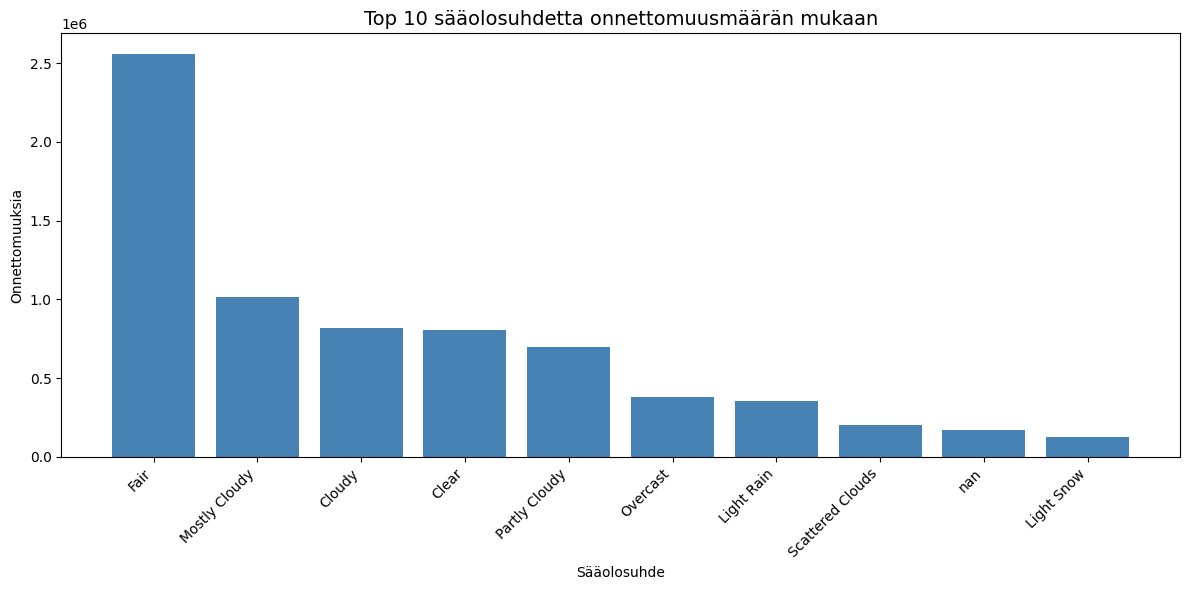

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

weather_pd = df.groupBy("Weather_Condition") \
    .agg(count("*").alias("onnettomuuksia"),
         round(avg("Severity"), 2).alias("keskivakavuus")) \
    .orderBy("onnettomuuksia", ascending=False) \
    .limit(10) \
    .toPandas()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(weather_pd["Weather_Condition"], 
              weather_pd["onnettomuuksia"],
              color="steelblue")
ax.set_title("Top 10 sääolosuhdetta onnettomuusmäärän mukaan", fontsize=14)
ax.set_xlabel("Sääolosuhde")
ax.set_ylabel("Onnettomuuksia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("weather_accidents.png", dpi=150)
plt.show()

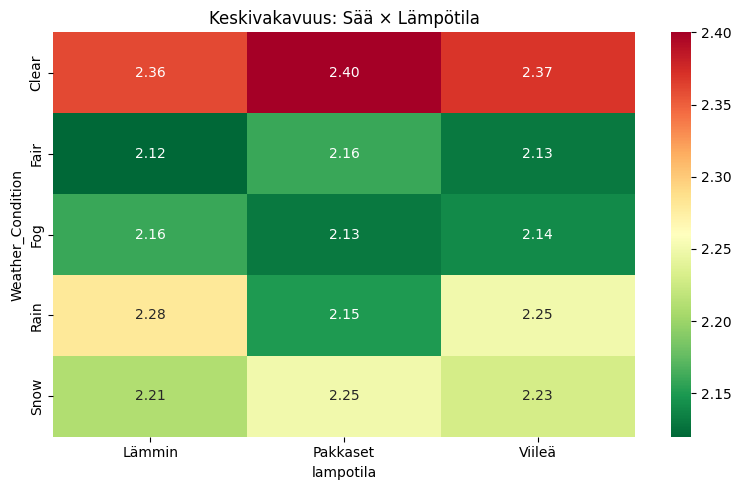

In [16]:
import seaborn as sns

pivot = ristianalyysi_pd.pivot(index="Weather_Condition", 
                                columns="lampotila", 
                                values="keskivakavuus")

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax)
ax.set_title("Keskivakavuus: Sää × Lämpötila")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()